# Baseline Models

The goal of this notebook is to establish simple reference models
before feature engineering and more complex algorithms.

## 1. Temporal split

Since `step` represents transaction time, the dataset is split
chronologically rather than randomly.

The final test period is reserved and will not be used for model
or feature selection.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (precision_score, recall_score,
                             average_precision_score,
                             accuracy_score, precision_recall_curve,
                             f1_score)

In [2]:
RANDOM_SEED = 42
df = pd.read_csv('../data/Synthetic_Financial_datasets_log.csv')

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
test_point = 550
calibration_point = test_point - 50
validation_point = calibration_point - 100

test = df[df['step'] > test_point].copy()
calibration = df[(df['step'] <= test_point) & (df['step'] > calibration_point)].copy()
validation = df[(df['step'] <= calibration_point) & (df['step'] > validation_point)].copy()
train = df[df['step'] <= validation_point].copy()

splits = {
    "train": train,
    "validation": validation,
    "calibration": calibration,
    "test": test,
}

total_positive = df["isFraud"].sum()

print(
    f"{'Split':<12}"
    f"{'Rows':>12}"
    f"{'% dataset':>12}"
    f"{'Frauds':>12}"
    f"{'% frauds':>12}"
    f"{'Fraud rate':>14}"
)

print("-" * 74)

for name, data in splits.items():
    rows = len(data)
    frauds = data["isFraud"].sum()

    dataset_share = rows / len(df) * 100
    fraud_share = frauds / total_positive * 100
    fraud_rate = frauds / rows * 100

    print(
        f"{name:<12}"
        f"{rows:>12,}"
        f"{dataset_share:>11.2f}%"
        f"{frauds:>12,}"
        f"{fraud_share:>11.2f}%"
        f"{fraud_rate:>13.4f}%"
    )

Split               Rows   % dataset      Frauds    % frauds    Fraud rate
--------------------------------------------------------------------------
train          5,787,030      90.95%       4,477      54.51%       0.0774%
validation       274,777       4.32%       1,084      13.20%       0.3945%
calibration      104,212       1.64%         504       6.14%       0.4836%
test             196,601       3.09%       2,148      26.15%       1.0926%


Fraud prevalence increases substantially over time, from 0.077%
in the training period to more than 1% in the final test period.

This indicates a strong temporal distribution shift and makes the
out-of-time validation setting considerably more challenging than
a random train/test split.

## 2. Leakage-safe feature set

In [5]:
leakage_safe_features = ['step', 'type', 'amount']

In [6]:
X_train, y_train = train.drop('isFraud', axis=1), train['isFraud']
X_val, y_val = validation.drop('isFraud', axis=1), validation['isFraud']
X_cal, y_cal = calibration.drop('isFraud', axis=1), calibration['isFraud']
X_test, y_test = test.drop('isFraud', axis=1), test['isFraud']

## 3. Existing rule baseline

In [7]:
isFlaggedFraud_precision = precision_score(y_val, X_val['isFlaggedFraud'], zero_division=0)
isFlaggedFraud_recall = recall_score(y_val, X_val['isFlaggedFraud'], zero_division=0)
isFlaggedFraud_accuracy = accuracy_score(y_val, X_val['isFlaggedFraud'])
isFlaggedFraud_f1 = f1_score(y_val, X_val['isFlaggedFraud'], zero_division=0)

print(f"{'isFlaggedFraud feature precision':35}: {isFlaggedFraud_precision:.4f}")
print(f"{'isFlaggedFraud feature recall':35}: {isFlaggedFraud_recall:.4f}")
print(f"{'isFlaggedFraud feature accuracy':35}: {isFlaggedFraud_accuracy:.4f}")
print(f"{'isFlaggedFraud feature f1':35}: {isFlaggedFraud_f1:.4f}")

isFlaggedFraud feature precision   : 1.0000
isFlaggedFraud feature recall      : 0.0018
isFlaggedFraud feature accuracy    : 0.9961
isFlaggedFraud feature f1          : 0.0037


## 4. Dummy classifier

In [8]:
dummy = DummyClassifier(strategy='prior')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_val)
dummy_proba = dummy.predict_proba(X_val)[:, 1]

dummy_precision = precision_score(y_val, dummy_pred, zero_division=0)
dummy_recall = recall_score(y_val, dummy_pred, zero_division=0)
dummy_accuracy = accuracy_score(y_val, dummy_pred)
dummy_ap = average_precision_score(y_val, dummy_proba)
dummy_f1 = f1_score(y_val, dummy_pred, zero_division=0)

print(f"{'Dummy precision':20}: {dummy_precision:.4f}")
print(f"{'Dummy recall':20}: {dummy_recall:.4f}")
print(f"{'Dummy accuracy':20}: {dummy_accuracy:.4f}")
print(f"{'Dummy f1':20}: {dummy_f1:.4f}")
print(f"{'Dummy Average Precision':20}: {dummy_ap:.4f}")

precision_dummy, recall_dummy, _ = precision_recall_curve(
    y_val,
    dummy_proba
)

Dummy precision     : 0.0000
Dummy recall        : 0.0000
Dummy accuracy      : 0.9961
Dummy f1            : 0.0000
Dummy Average Precision: 0.0039


## 5. Logistic Regression

In [9]:
preprocessor = ColumnTransformer(transformers=[
    ('numeric', StandardScaler(), ['step', 'amount']),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ['type'])
])

logreg_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight=None,
                                 random_state=RANDOM_SEED))
])

logreg_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced',
                                 random_state=RANDOM_SEED))
])

In [10]:
logreg_base.fit(X_train[leakage_safe_features], y_train)
logreg_base_pred = logreg_base.predict(X_val)
logreg_base_proba = logreg_base.predict_proba(X_val)[:, 1]

logreg_base_precision = precision_score(y_val, logreg_base_pred, zero_division=0)
logreg_base_recall = recall_score(y_val, logreg_base_pred, zero_division=0)
logreg_base_accuracy = accuracy_score(y_val, logreg_base_pred)
logreg_base_ap = average_precision_score(y_val, logreg_base_proba)
logreg_base_f1 = f1_score(y_val, logreg_base_pred, zero_division=0)

print(f"{'Logreg unbalanced precision':20}: {logreg_base_precision:.4f}")
print(f"{'Logreg unbalanced recall':20}: {logreg_base_recall:.4f}")
print(f"{'Logreg unbalanced accuracy':20}: {logreg_base_accuracy:.4f}")
print(f"{'Logreg unbalanced f1':20}: {logreg_base_f1:.4f}")
print(f"{'Logreg unbalanced Average Precision':20}: {logreg_base_ap:.4f}")

precision_log_unbalanced, recall_log_unbalanced, _ = precision_recall_curve(
    y_val,
    logreg_base_proba
)

Logreg unbalanced precision: 0.0000
Logreg unbalanced recall: 0.0000
Logreg unbalanced accuracy: 0.9961
Logreg unbalanced f1: 0.0000
Logreg unbalanced Average Precision: 0.0604


In [11]:
logreg_balanced.fit(X_train[leakage_safe_features], y_train)
logreg_balanced_pred = logreg_balanced.predict(X_val)
logreg_balanced_proba = logreg_balanced.predict_proba(X_val)[:, 1]

logreg_balanced_precision = precision_score(y_val, logreg_balanced_pred, zero_division=0)
logreg_balanced_recall = recall_score(y_val, logreg_balanced_pred, zero_division=0)
logreg_balanced_accuracy = accuracy_score(y_val, logreg_balanced_pred)
logreg_balanced_ap = average_precision_score(y_val, logreg_balanced_proba)
logreg_balanced_f1 = f1_score(y_val, logreg_balanced_pred, zero_division=0)

print(f"{'Logreg balanced precision':20}: {logreg_balanced_precision:.4f}")
print(f"{'Logreg balanced recall':20}: {logreg_balanced_recall:.4f}")
print(f"{'Logreg balanced accuracy':20}: {logreg_balanced_accuracy:.4f}")
print(f"{'Logreg balanced f1':20}: {logreg_balanced_f1:.4f}")
print(f"{'Logreg balanced Average Precision':20}: {logreg_balanced_ap:.4f}")

precision_log_balanced, recall_log_balanced, _ = precision_recall_curve(
    y_val,
    logreg_balanced_proba
)

Logreg balanced precision: 0.0326
Logreg balanced recall: 0.7334
Logreg balanced accuracy: 0.9131
Logreg balanced f1  : 0.0625
Logreg balanced Average Precision: 0.1075


## 6. Baseline comparison

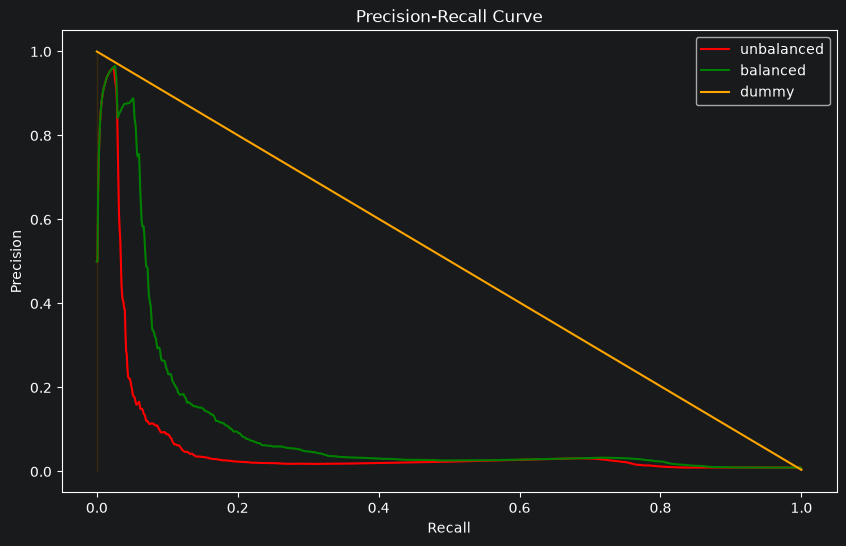

In [12]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    x=recall_log_unbalanced,
    y=precision_log_unbalanced,
    color='red',
    label='unbalanced'
)
sns.lineplot(
    x=recall_log_balanced,
    y=precision_log_balanced,
    color='green',
    label='balanced'
)
sns.lineplot(
    x=recall_dummy,
    y=precision_dummy,
    color='orange',
    label='dummy'
)

plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

In [13]:
pd.DataFrame({
    'Model': ['isFlaggedFraud', 'Dummy', 'Logreg unbalanced', 'Logreg balanced'],
    'Precision': [isFlaggedFraud_precision, dummy_precision, logreg_base_precision, logreg_balanced_precision],
    'Recall': [isFlaggedFraud_recall, dummy_recall, logreg_base_recall, logreg_balanced_recall],
    'F1': [isFlaggedFraud_f1, dummy_f1, logreg_base_f1, logreg_balanced_f1],
    'PR': ['-', round(dummy_ap, 3), round(logreg_base_ap, 3), round(logreg_balanced_ap, 3)]
}).round(3)

,Model,Precision,Recall,F1,PR
0,isFlaggedFraud,1.000,0.002,0.004,-
1,Dummy,0.000,0.000,0.000,0.004
2,Logreg unbalanced,0.000,0.000,0.000,0.06
3,Logreg balanced,0.033,0.733,0.062,0.107


## 7. Conclusions

## Baseline conclusions

The baseline experiments show that the existing rule-based system
has extremely high precision but detects only a very small fraction
of fraudulent transactions.

The unweighted Logistic Regression fails to classify fraud at the
default 0.5 threshold. However, its Average Precision indicates that
the predicted probabilities still contain useful ranking information.

Using balanced class weights substantially improves Average Precision
and recall. At the default threshold, the balanced model detects more
than 70% of fraudulent transactions, although precision remains low.

These results demonstrate that the problem is learnable even with a
minimal leakage-safe feature set (`step`, `type`, and `amount`).

The next stage will investigate whether feature engineering can improve
out-of-time ranking performance before more complex models are considered.